Imports

In [1]:
from pathlib import Path
from simple_graph import SimpleGraph

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"


Criação do grafo

In [2]:
file = Path.cwd() / "data" / "Email-Enron.txt"

def new_graph(file: Path):
  with file.open("r", encoding="utf-8") as f:
    V = int(f.readline())
    E = int(f.readline())
    g = SimpleGraph(V)
    for _ in range(E*2):
      v, w = f.readline().split()
      g.add_edge(v, w)
  return g

g = new_graph(file)

#### Métricas básicas

Print do grafo

In [ ]:
print(g)

Densidade e Grau médio

In [3]:
def density(graph):
  return 2 * graph.E / (graph.V * (graph.V - 1))

def medium_degree(graph):
  sum_degree = sum([graph.degree(i) for i in range(graph.V)])
  return sum_degree / graph.V
  

In [4]:
print(f"Densidade:\n\t{density(g)}\n")
print(f"Grau médio:\n\t{medium_degree(g)}")


Densidade:
	0.00027309755503535

Grau médio:
	10.020222391802028


In [5]:
degrees = [g.degree(i) for i in range(g.V)]

### Histograma

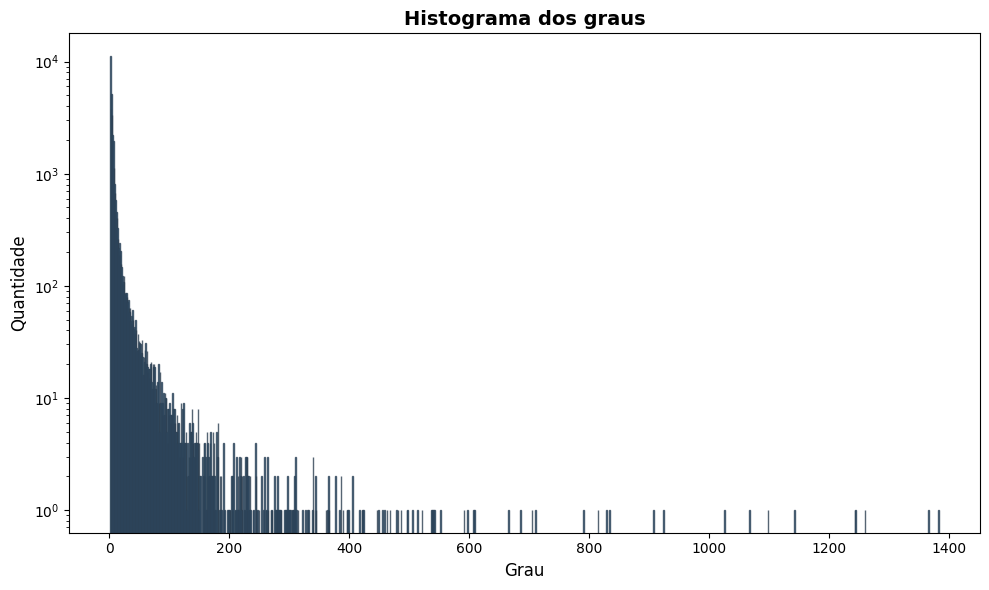

In [ ]:
df = pd.DataFrame({"degree": degrees})

plt.figure(figsize=(10, 6))

plt.hist(df['degree'], bins=g.max_degree(), #density=True, 
         color='#3498db', edgecolor='#2c3e50', alpha=0.8)

# plt.yscale('log')
# plt.grid(True, which="both", ls="--", alpha=0.2)

plt.title(r"Histograma dos graus", fontsize=14, fontweight='bold')
plt.xlabel("Grau", fontsize=12)
plt.ylabel("Quantidade", fontsize=12)

plt.tight_layout()

plt.show()

### Coeficiente de Clustering

O coeficiente de clustering mede **o quão conectados estão os vizinhos** de um vértice.

#### Coeficiente local (de um vértice $(i)$)
$$
C_i = \frac{2L_i}{k_i(k_i - 1)}
$$
onde:

- $(k_i)$: grau do vértice $(i)$ (número de vizinhos de $(i)$);
- $(L_i)$: número de arestas **entre os vizinhos** de $(i)$.

Interpretação:
- $(k_i(k_i-1)/2)$ é o número máximo de arestas possíveis entre os vizinhos;
- $(L_i)$ é o número real dessas arestas;
- portanto, $(C_i \in [0,1])$: quanto mais perto de 1, mais “fechada” é a vizinhança de $(i)$.

> Observação: se $(k_i < 2)$, normalmente define-se $(C_i = 0)$ (ou não definido, dependendo da convenção).

In [ ]:
def clustering_coeficiente_local(g, i):
    neighbors = g.adj[i].to_list()
    k_i = len(neighbors)

    if k_i < 2:
        return 0.0

    neighbors_set = set(neighbors)
    l_i = 0

    for u in neighbors:
        for v in g.adj[u]:
            if v in neighbors_set and u < v:
                l_i += 1

    return (2.0 * l_i) / (k_i * (k_i - 1))

### Coeficiente de Clustering médio
$${\displaystyle {\bar {C}}={\frac {1}{n}}\sum _{i=1}^{n}C_{i}.}$$

In [ ]:
def average_clustering_coeficiente(g):
    clustering_sum = 0
    for i in range(g.V):
        clustering_sum += clustering_coeficiente_local(g, i)
    return clustering_sum/g.V

print(f"Coeficiente de Clustering Médio: {average_clustering_coeficiente(g)}")

### Distribuição de grau $(p_k)$

Nesta etapa, calculamos a distribuição empírica de graus do grafo.
Para cada valor de grau \(k\), definimos:
$$
p_k \;=\; \frac{N_k}{N}

$$

onde:
- $N$ é o número total de vértices;
- $N_k$ é o número de vértices com grau \(k\);
- $p_k$ é a fração (probabilidade empírica) de vértices com grau \(k\).

Observação importante:
- para construir a distribuição corretamente, usamos os valores **únicos** de \(k\);
- nesse caso, a soma das probabilidades deve ser aproximadamente 1:
$$\sum_k p_k \approx 1$$


In [8]:
def nk(graph, k):
  count = 0
  for i in range(graph.V):
    if graph.degree(i) == k:
      count += 1
  return count

def n(graph):
  adj = graph.adj
  return len(adj)

def pk(graph, k):
  return nk(graph, k) / n(graph)

In [9]:
unique_k = sorted(set(degrees))
pk_list = [pk(g, k) for k in unique_k]

### Visualização da lei de potência

Nesta etapa comparamos duas visualizações da distribuição de grau:
- gráfico em escala normal (`log_x=False`, `log_y=False`): curva como \($p_k \sim k^{-\gamma}$\);
- gráfico em escala log-log (`log_x=True`, `log_y=True`): tendência aproximadamente linear.

A escala log-log ajuda a observar a tendência aproximadamente linear esperada em distribuições do tipo potência.

In [10]:
df = pd.DataFrame({
    "degree": unique_k,
    "probability": pk_list,
})

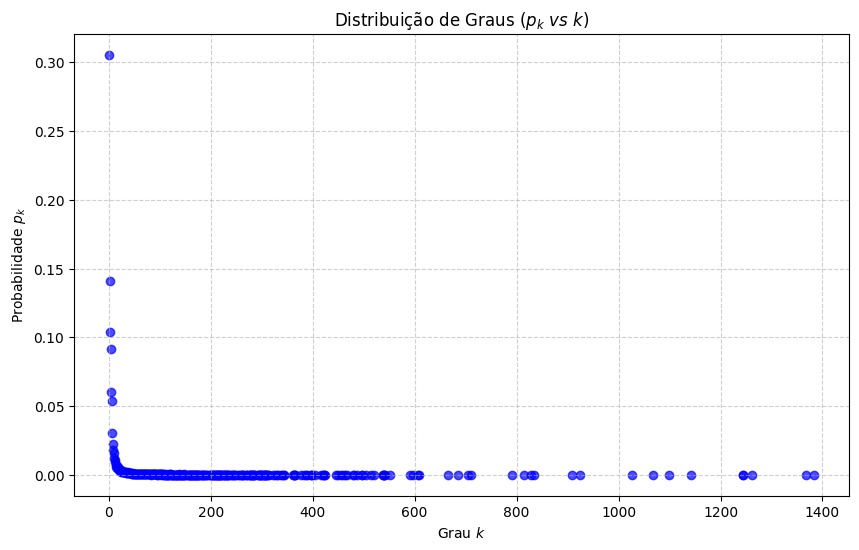

In [11]:
plt.figure(figsize=(10, 6))
plt.scatter(df['degree'], df['probability'], color='blue', alpha=0.7)

plt.title(r"Distribuição de Graus $(p_k\ vs\ k)$")
plt.xlabel(r"Grau $k$")
plt.ylabel(r"Probabilidade $p_k$")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

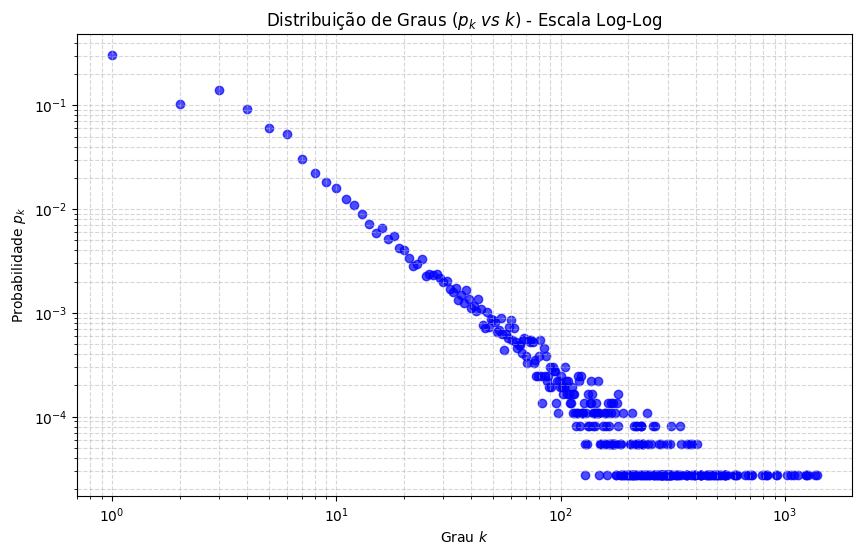

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df['degree'], df['probability'], color='blue', alpha=0.7)

plt.xscale('log')
plt.yscale('log')

plt.title(r"Distribuição de Graus $(p_k\ vs\ k)$ - Escala Log-Log")
plt.xlabel(r"Grau $k$")
plt.ylabel(r"Probabilidade $p_k$")

plt.grid(True, which="both", linestyle='--', alpha=0.5)

plt.show()

### Estimativa do Expoente $\gamma$
Para redes que seguem uma Lei de Potência, a probabilidade de um nó possuir grau $k$ é dada por:

$$p_k \sim k^{-\gamma}$$

$$p_k \;=\; C k^{-\gamma}$$

> A constante C é determinada pela condição de normalização.

Ao aplicarmos o logaritmo em ambos os lados da equação, transformamos a relação de potência em uma relação linear:

$$\log(p_k) \approx -\gamma \log(k) + \log(C)$$

Esta equação segue o formato da reta $y = ax + b$, onde:

$y$: $\log(p_k)$ 

$x$: $\log(k)$ 

$a$ (Coeficiente Angular): $-\gamma$ 

$b$ (Intercepto): $\log(C)$

> Interpretação Visual: No gráfico de escala log-log, o expoente $\gamma$ corresponde à inclinação negativa da reta. Quanto mais inclinada a reta, mais rápida é a queda na probabilidade de encontrar nós com graus muito elevados.

In [13]:
log_k = np.log(df["degree"].to_numpy())
log_pk = np.log(df["probability"].to_numpy())

slope, intercept = np.polyfit(log_k, log_pk, 1)
gamma = -slope

print(f"gamma estimado: {gamma:.4f}")
print(f"C estimado: {np.exp(intercept):.4f}")

gamma estimado: 1.5449
C estimado: 0.2766


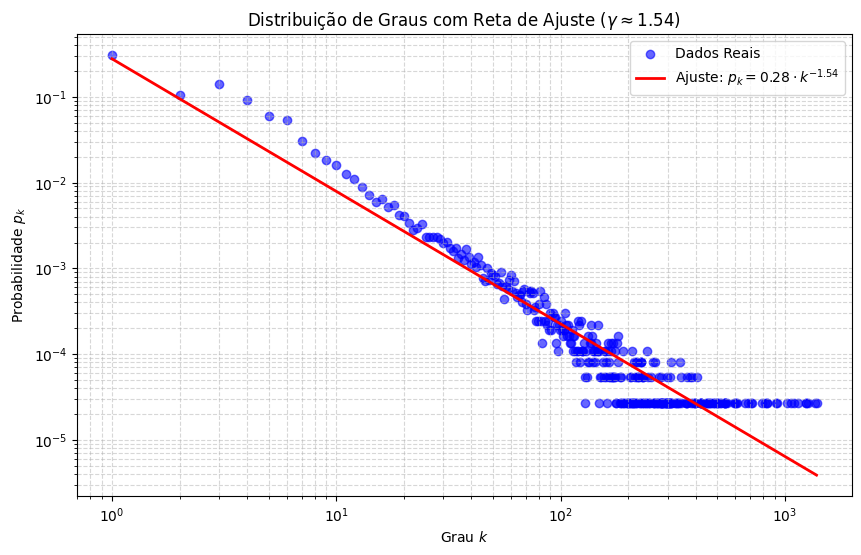

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df["degree"], df["probability"], color='blue', alpha=0.6, label='Dados Reais')

# Criando a linha da "Lei de Potência Teórica" usando Gamma e C
k_teorico = np.linspace(df["degree"].min(), df["degree"].max(), 100)

# P(k) = C * k^(-gamma)
pk_teorico = np.exp(intercept) * (k_teorico**(-gamma)) 

plt.plot(k_teorico, pk_teorico, color='red', linewidth=2, 
         label=fr'Ajuste: $p_k = {np.exp(intercept):.2f} \cdot k^{{{slope:.2f}}}$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Grau $k$")
plt.ylabel("Probabilidade $p_k$")
plt.title(fr"Distribuição de Graus com Reta de Ajuste ($\gamma \approx {gamma:.2f}$)")

plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

In summary, networks whose degree distribution follows a power law are called scale-free networks. If a network is directed, the scale-free property applies separately to the in- and the out-degrees. To mathematically study the properties of scale-free networks, we can use either the discrete or the continuum formalism. The scale-free property is independent of the formalism we use.



#### Fontes
https://networksciencebook.com/chapter/3#clustering-3-9